# Modélisation de Stratégies de Tendance : Golden Cross & Death Cross

**Auteur :** ISLEYEN Volkan
**Statut :** Étudiant L3 Économie & Gestion
**Objectif :** Application des méthodes d'analyse technique via Python
**Stack :** Pandas, Matplotlib, Yfinance

---

## Contexte du Projet

Dans le cadre de ma préparation au **Master Finance de Marché**, ce projet vise à développer des compétences pratiques en **analyse quantitative**. L'objectif est de programmer et de visualiser des indicateurs de suivi de tendance (*Trend Following*) couramment utilisés en salle de marchés.

Contrairement à l'Hypothèse des Marchés Eficients (HME), l'analyse technique postule que les prix suivent des tendances identifiables. Ce notebook modélise l'interaction entre deux horizons temporels pour générer des signaux de trading théoriques.

## Objectifs Techniques & Financiers

1.  **Manipulation de Séries Temporelles :**
    * Extraction des données OHLC (Open, High, Low, Close) via API.
    * Nettoyage et structuration des DataFrames.

2.  **Construction d'Indicateurs (Feature Engineering) :**
    * Calcul de la **Moyenne Mobile Arithmétique 50 jours (SMA 50)** : Représente la tendance court/moyen terme et le sentiment actuel du marché.
    * Calcul de la **Moyenne Mobile Arithmétique 200 jours (SMA 200)** : Représente la tendance structurelle de long terme (souvent utilisée comme support/résistance majeur).

3.  **Visualisation des Signaux :**
    * Identification graphique des points de croisement.
    * **Golden Cross :** La SMA 50 croise la SMA 200 à la hausse (Signal Haussier).
    * **Death Cross :** La SMA 50 croise la SMA 200 à la baisse (Signal Baissier).

## Méthodologie

J'utilise ici une approche vectorisée avec la bibliothèque `pandas` pour optimiser les temps de calcul sur les grands historiques de données, plutôt que des boucles itératives classiques.

In [13]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

tesla = yf.download('TSLA', start='2020-01-01', end='2024-12-31')
tesla.columns = tesla.columns.droplevel('Ticker')
tesla.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [14]:
tesla.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [16]:
tesla["SMA_50"] = tesla["Close"].rolling(window=50).mean()

In [17]:
tesla["SMA_200"] = tesla["Close"].rolling(window=200).mean()

In [19]:
tesla.tail()

Price,Close,High,Low,Open,Volume,SMA_50,SMA_200
Date,,,,,,,
2024-12-23,430.600006,434.510010,415.410004,431.000000,72698100,324.8296,232.24500
2024-12-24,462.279999,462.779999,435.140015,435.899994,59551800,329.6920,233.66755
2024-12-26,454.130005,465.329987,451.019989,465.160004,76366400,334.3832,235.05050
2024-12-27,431.660004,450.000000,426.500000,449.519989,82666800,338.5898,236.36140
2024-12-30,417.410004,427.000000,415.750000,419.399994,64941000,342.5202,237.63595


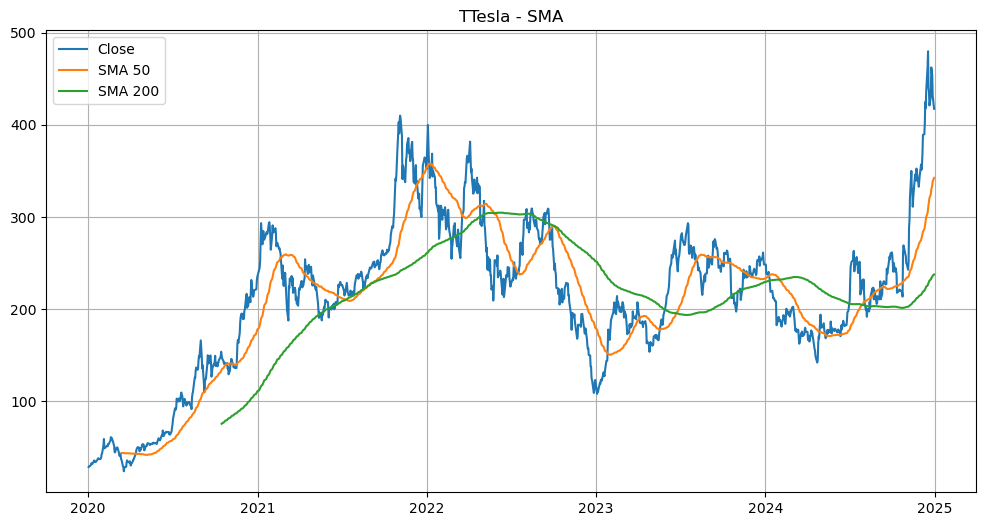

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(tesla['Close'], label='Close')
plt.plot(tesla['SMA_50'], label='SMA 50')
plt.plot(tesla['SMA_200'], label='SMA 200')
plt.title('TTesla - SMA')
plt.legend()
plt.grid(True)
plt.show()